# 📧 Email Spam Detection with NLP
**Goal:** binary classifier (spam vs ham) using TF-IDF + Multinomial Naive Bayes, Logistic Regression and Linear SVM.

**Dataset:** Enron Email Spam corpus (also on Kaggle) - ~33,000 real emails (subject + body) labelled spam/ham. Downloaded automatically by `utils.load_data()`.

**Pipeline:** load -> class check -> preprocess -> TF-IDF -> split -> train 3 models -> evaluate -> WordClouds -> save model for the web app.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt, seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from utils import load_data, clean_text   # shared with the web app
sns.set_theme(style="whitegrid")

## 1. Load data & class distribution

In [2]:
df = load_data()
print("Shape:", df.shape, "| duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)   # duplicates would leak between train/test
counts = df["label"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(2)}))
df.head()

Shape: (33665, 2) | duplicates: 3172
       count  percent
label                
ham    15910    52.18
spam   14583    47.82


,label,text
0,ham,christmas tree farm pictures .
1,ham,"vastar resources , inc . . gary , production f..."
2,ham,calpine daily gas nomination . - calpine daily...
3,ham,re : issue . fyi - see note below - already do...
4,ham,meter 7268 nov allocation . fyi .\n- - - - - -...


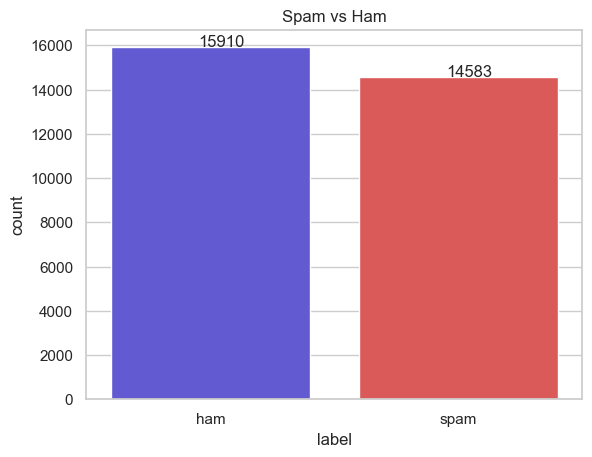

In [3]:
# Visualise the class balance
ax = sns.countplot(x="label", data=df, palette=["#4f46e5", "#ef4444"])
for p in ax.patches: ax.annotate(int(p.get_height()), (p.get_x()+0.35, p.get_height()+20))
plt.title("Spam vs Ham"); plt.show()

## 2. Text preprocessing
Steps (see `utils.clean_text`): lowercase -> strip HTML tags, email addresses & URLs -> remove punctuation & digits -> remove stopwords (NLTK) -> Porter stemming.

In [4]:
df["clean"] = df["text"].apply(clean_text)
df["length"] = df["text"].str.len()   # characters in subject+body
display(df[["text", "clean"]].head(5))
df.groupby("label")["length"].describe()   # compare email lengths

,text,clean
0,christmas tree farm pictures .,christma tree farm pictur
1,"vastar resources , inc . . gary , production f...",vastar resourc inc gari product high island la...
2,calpine daily gas nomination . - calpine daily...,calpin daili ga nomin calpin daili ga nomin doc
3,re : issue . fyi - see note below - already do...,issu fyi see note alreadi done stella forward ...
4,meter 7268 nov allocation . fyi .\n- - - - - -...,meter nov alloc fyi forward lauri allen hou ec...


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,15910.0,1627.424701,5394.739766,6.0,342.0,792.0,1676.75,228370.0
spam,14583.0,1317.014400,1934.589960,5.0,351.0,652.0,1387.50,28754.0


## 3. Feature extraction - TF-IDF
**TF-IDF (Term Frequency - Inverse Document Frequency)** scores how important a word is to a document within a corpus.
- **TF** = how often the word appears in this message (frequent in the message -> more relevant to it).
- **IDF** = `log(N / df)`: down-weights words appearing in many messages (like "the", "will") and boosts rare, distinctive words (like "claim", "prize").
- **TF x IDF** is high for words that are frequent in *one* message but rare overall - exactly the words that discriminate spam from ham.

Compared with raw counts it stops very common words from dominating. We also use unigrams + bigrams.

## 4. Train/test split
Stratified 80/20 so both sets keep the same spam ratio.

In [5]:
y = (df["label"] == "spam").astype(int)
X_train, X_test, y_train, y_test = train_test_split(df["clean"], y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, "| spam share train/test:", y_train.mean().round(3), y_test.mean().round(3))

(24394,) (6099,) | spam share train/test: 0.478 0.478


## 5. Train classifiers
TF-IDF is inside a `Pipeline` so it's fitted only on training data (no leakage).

In [6]:
models = {
    "Multinomial NB":      MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM":          LinearSVC(class_weight="balanced"),
}
pipes, results = {}, []
for name, clf in models.items():
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True), clf).fit(X_train, y_train)
    pred = pipe.predict(X_test); pipes[name] = pipe
    results.append({"Model": name, "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred)})
res = pd.DataFrame(results).set_index("Model").round(4)
res

,Accuracy,Precision,Recall,F1
Model,,,,
Multinomial NB,0.9885,0.9860,0.9901,0.9880
Logistic Regression,0.9872,0.9788,0.9949,0.9867
Linear SVM,0.9921,0.9874,0.9962,0.9918


## 6. Evaluation - metrics & confusion matrices


===== Multinomial NB =====
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      3182
        spam       0.99      0.99      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099


===== Logistic Regression =====
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99      3182
        spam       0.98      0.99      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099


===== Linear SVM =====
              precision    recall  f1-score   support

         ham       1.00      0.99      0.99      3182
        spam       0.99      1.00      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99

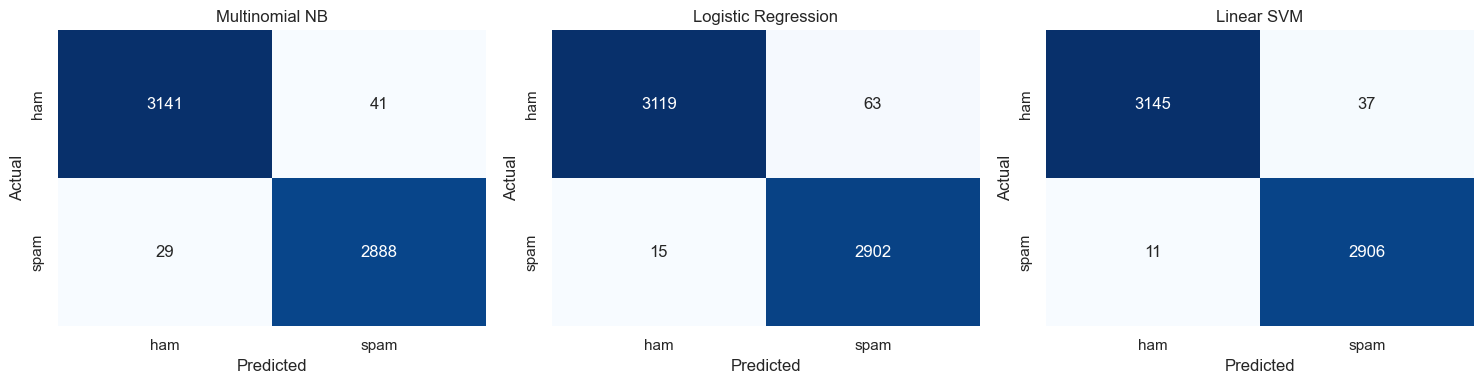

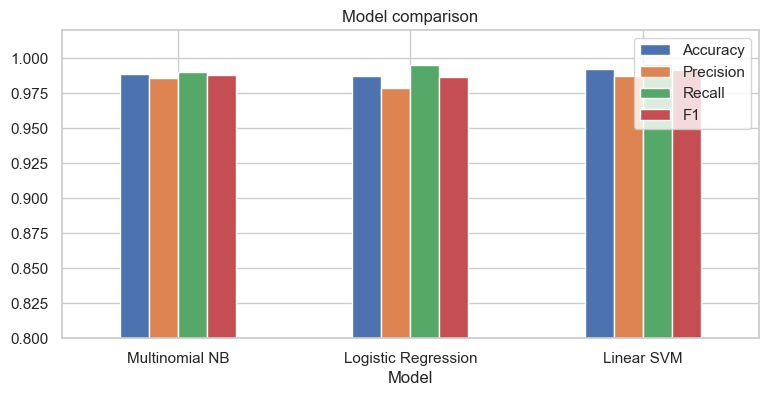

In [7]:
for name, pipe in pipes.items():
    print(f"\n===== {name} =====")
    print(classification_report(y_test, pipe.predict(X_test), target_names=["ham", "spam"]))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, pipes.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()
res.plot(kind="bar", figsize=(9, 4), ylim=(0.8, 1.02), title="Model comparison"); plt.xticks(rotation=0); plt.show()

## 7. Discussion - why is recall important for spam detection?
**Recall = TP / (TP + FN)**: of all real spam, how much did we catch? Every missed spam (false negative) lands in the inbox, where it can carry phishing links, malware or scams - so a low recall means users are actually exposed to harm and stop trusting the filter.

**But there is a trade-off:** a false positive (a legit email sent to spam) can be just as costly - a missed job offer or invoice. Pushing recall to 100% by flagging everything would destroy **precision**. That is why we report **F1** (harmonic mean) and look at the confusion matrix. In practice, spam filters aim for very high recall while keeping false positives extremely low, often by tuning the decision threshold.

Even on a balanced dataset like this one (~51% spam) accuracy hides *which* error is made - on real inboxes spam is often the majority or minority depending on the user, so always check recall and precision separately.

## 8. (Bonus) WordClouds

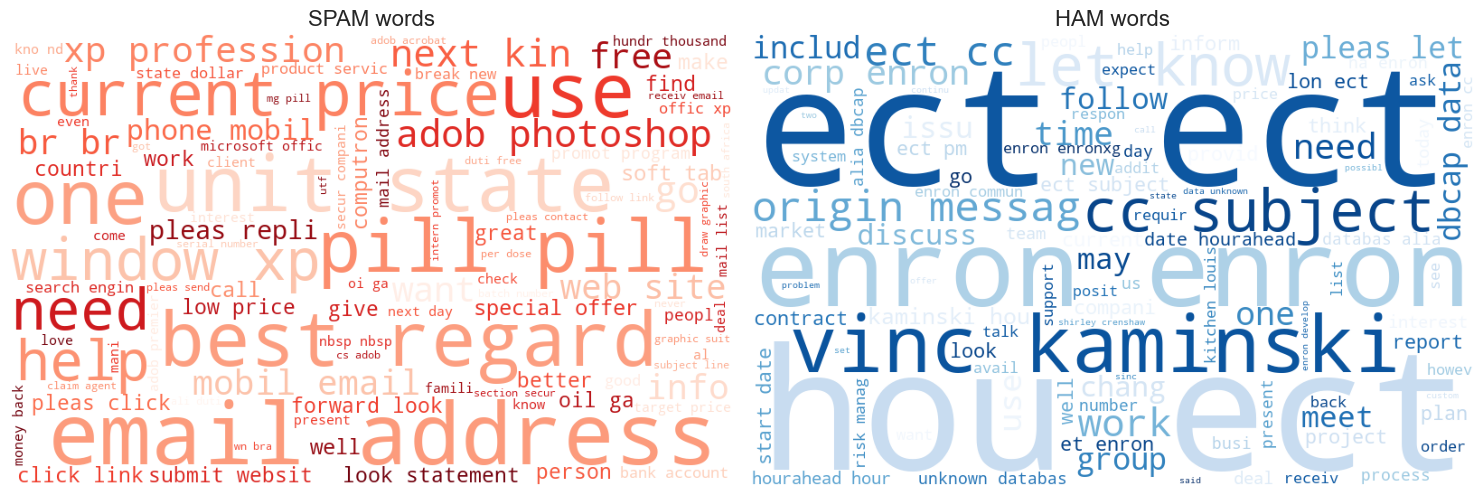

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lab, cmap in zip(axes, ["spam", "ham"], ["Reds", "Blues"]):
    text = " ".join(df.loc[df["label"] == lab, "clean"])
    ax.imshow(WordCloud(width=800, height=500, background_color="white", colormap=cmap, max_words=100).generate(text))
    ax.set_title(f"{lab.upper()} words", fontsize=16); ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Top spam-indicating words (Logistic Regression coefficients)

In [9]:
lr = pipes["Logistic Regression"]
vec, clf = lr.steps[0][1], lr.steps[1][1]
coef = pd.Series(clf.coef_[0], index=vec.get_feature_names_out()).sort_values()
print("Most SPAM-like:", list(coef.tail(15).index[::-1])); print("Most HAM-like :", list(coef.head(15).index))

Most SPAM-like: ['http', 'remov', 'softwar', 'money', 'onlin', 'life', 'medic', 'click', 'save', 'watch', 'email', 'free', 'site', 'qualiti', 'med']
Most HAM-like : ['enron', 'vinc', 'thank', 'attach', 'louis', 'schedul', 'deal', 'question', 'enron com', 'ga', 'pleas', 'houston', 'energi', 'let know', 'pm']


## 10. Try it & save the best model for the web app

In [10]:
def predict(msg, name="Linear SVM"):
    return "SPAM" if pipes[name].predict([clean_text(msg)])[0] else "HAM"
for m in ["Subject: URGENT - you have won $1,000,000! Click http://claim-prize.biz now to claim your free reward", "Subject: Meeting notes. Hi John, attached are the notes from today's project meeting. Please review before Friday."]:
    print(predict(m), "->", m)

best = res["F1"].idxmax(); print("Best by F1:", best)
joblib.dump({"model": pipes[best], "name": best}, "model/spam_model.joblib")   # loaded by app.py

SPAM -> Subject: URGENT - you have won $1,000,000! Click http://claim-prize.biz now to claim your free reward
HAM -> Subject: Meeting notes. Hi John, attached are the notes from today's project meeting. Please review before Friday.
Best by F1: Linear SVM


['model/spam_model.joblib']